# 99_explore — 실험별 시각화 탐색 도구 (Utility)

> ⚠️ **본 노트북은 utility 도구** — 발표 본문 자료가 아닌 **개발/Q&A 백업** 용. 정형 분석은 [05b_Analyze](05b_Analyze.ipynb) / [06_Regime_Analysis](06_Regime_Analysis.ipynb) 가 담당.

**목적**: `final_pt/results/*.pkl` 의 임의 실험 1 개 (또는 여러 개) 를 입력만 바꿔 즉석 시각화.

## 모듈형 함수

| 함수 | 입력 | 출력 |
|---|---|---|
| `list_results()` | — | results/ 의 pkl 이름 list |
| `load_result(name)` | 실험명 | 결과 dict |
| `metrics_summary(names, period)` | 실험명 list | metrics 표 (DataFrame) |
| `plot_single(name, period)` | 1 개 실험명 | 종합 패널 6 차트 (cumret·DD·hist·rolling Sharpe·eff_n·turnover) |
| `plot_compare(names, period)` | 여러 실험명 | 비교 차트 4 패널 (cumret·DD·metrics bar·rolling Sharpe) |
| `plot_weights(name, n_top)` | 실험명, top n | 종목별 가중치 heatmap (시계열) |

## 사용 시점

- 청중이 발표 중 "X 실험의 누적 수익은?" 같은 질문 → 셀 1 줄 수정 후 즉시 답변
- 발표 준비 중 특정 실험의 detail 점검 (drawdown 구간, top 종목 변화 등)
- 새로운 슬롯 조합 시도 후 빠른 sanity check

## 기본 period

함수 default `period=('2010-01', '2023-12')` — 05b/06 와 동일한 K_CUT (TEST 168m). hold-out 24m 까지 보고 싶으면 `('2010-01', '2025-12')` 지정.

## 사용법

맨 아래 "사용 예시" 셀의 `name`, `names`, `period` 변수만 수정 → 실행.

In [1]:
# ─── 임포트 + 한글 폰트 설정 ────────────────────────────────────────
import pickle
import platform
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    import koreanize_matplotlib  # noqa
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

import sys
sys.path.insert(0, str(Path.cwd().parent))   # final_pt/ 에서 모듈 import
from bl_functions import compute_metrics

# ─── 경로 ────────────────────────────────────────────────────────────
BASE_DIR    = Path.cwd().parent   # appendix/ → final_pt/
DATA_DIR    = BASE_DIR / 'data'
RESULTS_DIR = BASE_DIR / 'results'

print(f'결과 폴더: {RESULTS_DIR}')
print(f'  pkl 갯수: {len(list(RESULTS_DIR.glob("*.pkl")))}개')

결과 폴더: /Users/yoonseokim/2025_main_bootcamp/4th_final_project/finance_project/final_pt/results
  pkl 갯수: 90개


In [2]:
# ─── 공통 데이터 로드 (rf, spy) ─────────────────────────────────────
panel = pd.read_csv(DATA_DIR / 'monthly_panel.csv', parse_dates=['date'])
panel = panel.set_index(['date', 'ticker'])
rf_series  = panel['rf_1m'].groupby(level='date').first()
spy_series = panel['spy_ret'].groupby(level='date').first()


def list_results():
    """results/ 폴더의 모든 pkl 이름 반환 (확장자 제외, 정렬)."""
    return sorted([p.stem for p in RESULTS_DIR.glob('*.pkl')])


def load_result(name):
    """단일 실험 pkl 로드."""
    path = RESULTS_DIR / f'{name}.pkl'
    if not path.exists():
        raise FileNotFoundError(f'{path} 없음. list_results() 로 확인.')
    with open(path, 'rb') as f:
        return pickle.load(f)


def get_period_data(res, period):
    """기간 trim 한 ret/rf/spy 시리즈 반환."""
    start, end = period
    ret = res['ret'].loc[start:end]
    rf  = rf_series.loc[start:end]
    spy = spy_series.loc[start:end]
    return ret, rf, spy


print(f'로드 가능한 실험: {len(list_results())}개')
print(f'예: {list_results()[:5]}')

로드 가능한 실험: 90개
예: ['mat_eq_eq_fix_he', 'mat_eq_eq_fix_pap', 'mat_eq_eq_inv_he', 'mat_eq_eq_inv_pap', 'mat_eq_eq_lam_he']


In [3]:
# ─── 모듈 1: metrics 표 ─────────────────────────────────────────────
def metrics_summary(names, period=('2010-01', '2023-12')):
    """여러 실험의 metrics 표 (DataFrame 반환).

    Parameters
    ----------
    names  : list[str]   실험명 리스트
    period : (start, end) 분석 기간
    """
    rows = []
    for name in names:
        try:
            res = load_result(name)
        except FileNotFoundError:
            rows.append({'name': name, 'note': 'pkl 없음'})
            continue
        ret, rf, spy = get_period_data(res, period)
        if len(ret) == 0:
            rows.append({'name': name, 'note': '데이터 없음'})
            continue
        m = compute_metrics(ret, rf, label=name, mkt_ret=spy)
        rows.append({
            'name'    : name,
            'n_month' : len(ret),
            'Sharpe'  : m['sharpe'],
            'Sortino' : m['sortino'],
            'CAGR'    : m['cagr'],
            'Vol'     : m['vol'],
            'MDD'     : m['mdd'],
            'Calmar'  : m['calmar'],
            'Beta'    : m['beta'],
            'Alpha'   : m['alpha'],
            'WinRate' : m['win_rate'],
        })
    df = pd.DataFrame(rows)
    return df


# ─── 사용 예시 ─────────────────────────────────────────────────────
# baseline (mat_mcap_mcap_fix_he) vs winner (mat_eq_eq_raw_pap) + pw 변형 비교
summary = metrics_summary(['mat_mcap_mcap_fix_he', 'mat_eq_eq_raw_pap', 'mat_eq_mcap_raw_pap', 'mat_eq_rp_raw_pap'])
summary

,name,n_month,Sharpe,Sortino,CAGR,Vol,MDD,Calmar,Beta,Alpha,WinRate
0,mat_mcap_mcap_fix_he,168,0.943,1.439,0.1163,0.1140,-0.1246,0.934,-0.118,0.1226,0.643
1,mat_eq_eq_raw_pap,168,1.096,1.826,0.1625,0.1385,-0.1365,1.191,-0.181,0.1745,0.643
2,mat_eq_mcap_raw_pap,168,0.988,1.641,0.1473,0.1403,-0.1695,0.869,-0.182,0.1615,0.607
3,mat_eq_rp_raw_pap,168,1.069,1.777,0.1569,0.1373,-0.1387,1.132,-0.171,0.1681,0.637


In [4]:
# ─── 모듈 2: 단일 실험 종합 시각화 (6 panels) ───────────────────────
def plot_single(name, period=('2010-01', '2023-12'), figsize=(15, 10)):
    """단일 실험의 종합 진단 패널.

    1. 누적수익률 (vs SPY)
    2. Drawdown 곡선
    3. 월별 수익률 히스토그램
    4. 12개월 rolling Sharpe
    5. 포트폴리오 구성 (eff_n + top10_share)
    6. 거래비용·turnover
    """
    res = load_result(name)
    ret, rf, spy = get_period_data(res, period)
    cfg = res['config']

    fig, axes = plt.subplots(3, 2, figsize=figsize)
    fig.suptitle(f'[{name}]  기간 {ret.index[0].date()} ~ {ret.index[-1].date()}  ({len(ret)}개월)',
                 fontsize=13, fontweight='bold')

    # 1. 누적수익률 vs SPY
    ax = axes[0, 0]
    cum_ret = (1 + ret).cumprod()
    cum_spy = (1 + spy.fillna(0)).cumprod()
    ax.plot(cum_ret.index, cum_ret.values, label=name, color='C0', linewidth=1.5)
    ax.plot(cum_spy.index, cum_spy.values, label='SPY', color='gray', linestyle='--', linewidth=1.2)
    ax.set_title('누적수익률 (1.0 시작)')
    ax.set_yscale('log')
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(True, alpha=0.3)

    # 2. Drawdown
    ax = axes[0, 1]
    dd = (cum_ret - cum_ret.cummax()) / cum_ret.cummax()
    ax.fill_between(dd.index, dd.values, 0, color='C3', alpha=0.4)
    ax.plot(dd.index, dd.values, color='C3', linewidth=1.0)
    ax.set_title(f'Drawdown (MDD = {dd.min()*100:.2f}%)')
    ax.set_ylabel('손실률')
    ax.grid(True, alpha=0.3)

    # 3. 월별 수익률 분포
    ax = axes[1, 0]
    ax.hist(ret.values * 100, bins=40, color='C0', alpha=0.7, edgecolor='black', linewidth=0.4)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.axvline(ret.mean() * 100, color='C3', linestyle='--', linewidth=1.0,
               label=f'평균 {ret.mean()*100:.2f}%')
    ax.set_title('월별 수익률 분포 (%)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # 4. 12개월 rolling Sharpe
    ax = axes[1, 1]
    excess = ret - rf.fillna(0)
    rolling_sharpe = excess.rolling(12).mean() / excess.rolling(12).std() * np.sqrt(12)
    ax.plot(rolling_sharpe.index, rolling_sharpe.values, color='C2', linewidth=1.2)
    ax.axhline(0, color='black', linewidth=0.6)
    ax.axhline(rolling_sharpe.mean(), color='C3', linestyle='--', linewidth=0.8,
               label=f'평균 {rolling_sharpe.mean():.2f}')
    ax.set_title('12개월 rolling Sharpe')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # 5. 포트폴리오 구성: effective N
    ax = axes[2, 0]
    comp = res['comp'].loc[period[0]:period[1]]
    if 'eff_n' in comp.columns:
        ax.plot(comp.index, comp['eff_n'].values, color='C0', linewidth=1.0, label='effective N')
        ax.set_ylabel('eff_n', color='C0')
        ax2 = ax.twinx()
        ax2.plot(comp.index, comp['top10_share'].values * 100, color='C1', linewidth=1.0, label='top10 share')
        ax2.set_ylabel('top10 share (%)', color='C1')
        ax.set_title(f'포트폴리오 분산도 (eff_n 평균 {comp["eff_n"].mean():.0f})')
    ax.grid(True, alpha=0.3)

    # 6. 거래비용·turnover
    ax = axes[2, 1]
    if 'turnover' in comp.columns:
        ax.bar(comp.index, comp['turnover'].values, color='C0', alpha=0.6, width=20)
        ax.set_ylabel('turnover')
        ax.set_title(f'월별 turnover (평균 {comp["turnover"].mean():.2f}, '
                     f'tc 비용 누적 {comp["tc_cost"].sum()*100:.2f}%)')
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # 텍스트 요약 — config + metrics
    print(f'\n[Config]')
    for k, v in cfg.items():
        if k in ('lstm_pred_path', 'name'):
            continue
        print(f'  {k:<15} = {v}')
    m = compute_metrics(ret, rf, label=name, mkt_ret=spy)
    print(f'\n[Metrics]')
    print(f'  Sharpe   = {m["sharpe"]:.3f}')
    print(f'  Sortino  = {m["sortino"]:.3f}')
    print(f'  CAGR     = {m["cagr"]*100:.2f}%')
    print(f'  Vol      = {m["vol"]*100:.2f}%')
    print(f'  MDD      = {m["mdd"]*100:.2f}%')
    print(f'  Calmar   = {m["calmar"]:.3f}')
    print(f'  Beta     = {m["beta"]:.3f}')
    print(f'  Alpha    = {m["alpha"]*100:.2f}%')
    print(f'  WinRate  = {m["win_rate"]*100:.1f}%')

In [5]:
# ─── 모듈 3: 여러 실험 비교 시각화 ──────────────────────────────────
def plot_compare(names, period=('2010-01', '2023-12'),
                 include_spy=True, figsize=(15, 10)):
    """여러 실험 비교 패널 — 4 panels.

    1. 누적수익률 비교
    2. Drawdown 비교
    3. Sharpe·CAGR·MDD 막대
    4. 12M rolling Sharpe 비교
    """
    rets = {}
    for name in names:
        try:
            res = load_result(name)
            r, _, _ = get_period_data(res, period)
            rets[name] = r
        except FileNotFoundError:
            print(f'⚠ {name} 없음 — 건너뜀')
    if not rets:
        print('표시할 실험 없음')
        return

    spy = spy_series.loc[period[0]:period[1]].fillna(0)

    fig, axes = plt.subplots(2, 2, figsize=figsize)
    fig.suptitle(f'실험 비교 ({len(rets)}개)  기간 {period[0]} ~ {period[1]}',
                 fontsize=13, fontweight='bold')

    # 색상 cycle
    colors = plt.cm.tab10(np.linspace(0, 1, max(len(rets), 10)))

    # 1. 누적수익률
    ax = axes[0, 0]
    for i, (name, r) in enumerate(rets.items()):
        cum = (1 + r).cumprod()
        ax.plot(cum.index, cum.values, label=name, color=colors[i], linewidth=1.3)
    if include_spy:
        cum_spy = (1 + spy).cumprod()
        ax.plot(cum_spy.index, cum_spy.values, label='SPY', color='black',
                linestyle='--', linewidth=1.0, alpha=0.6)
    ax.set_title('누적수익률')
    ax.set_yscale('log')
    ax.legend(loc='upper left', fontsize=8, ncol=1)
    ax.grid(True, alpha=0.3)

    # 2. Drawdown
    ax = axes[0, 1]
    for i, (name, r) in enumerate(rets.items()):
        cum = (1 + r).cumprod()
        dd  = (cum - cum.cummax()) / cum.cummax()
        ax.plot(dd.index, dd.values, label=name, color=colors[i], linewidth=1.0)
    ax.set_title('Drawdown')
    ax.legend(loc='lower left', fontsize=8)
    ax.grid(True, alpha=0.3)

    # 3. metrics 막대 (Sharpe / Sortino / |MDD|) — 각 메트릭 자체 스케일 보존, 색상으로 구분
    ax = axes[1, 0]
    metrics_df = metrics_summary(list(rets.keys()), period)
    x = np.arange(len(metrics_df))
    n_exp = len(metrics_df)
    width = 0.28
    # Sharpe & Sortino — 좌측 axis (위험조정 수익, 단위 동일)
    b1 = ax.bar(x - width, metrics_df['Sharpe'].astype(float),  width,
                label='Sharpe', color='#2E86AB')
    b2 = ax.bar(x,         metrics_df['Sortino'].astype(float), width,
                label='Sortino', color='#06A77D')
    for bars in [b1, b2]:
        for b in bars:
            ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.02,
                    f'{b.get_height():.2f}', ha='center', fontsize=7)
    ax.set_ylabel('Sharpe / Sortino', color='black', fontsize=10)
    ax.tick_params(axis='y', labelcolor='black')
    # |MDD| — 우측 axis (% 단위 별도 표시)
    ax_r = ax.twinx()
    mdd_abs = metrics_df['MDD'].astype(float).abs() * 100
    b3 = ax_r.bar(x + width, mdd_abs, width, label='|MDD| (%)',
                  color='#E63946', alpha=0.85)
    for b in b3:
        ax_r.text(b.get_x()+b.get_width()/2, b.get_height()+0.3,
                  f'{b.get_height():.1f}%', ha='center', fontsize=7)
    ax_r.set_ylabel('|MDD| (%)', color='#E63946', fontsize=10)
    ax_r.tick_params(axis='y', labelcolor='#E63946')
    ax.set_xticks(x)
    ax.set_xticklabels(metrics_df['name'].values, rotation=45, ha='right', fontsize=8)
    ax.set_title('Sharpe · Sortino · |MDD|')
    # 통합 legend
    lines_left, labels_left = ax.get_legend_handles_labels()
    lines_right, labels_right = ax_r.get_legend_handles_labels()
    ax.legend(lines_left + lines_right, labels_left + labels_right,
              fontsize=8, loc='upper left')
    ax.grid(True, alpha=0.3, axis='y')

    # 4. 12개월 rolling Sharpe
    ax = axes[1, 1]
    rf = rf_series.loc[period[0]:period[1]].fillna(0)
    for i, (name, r) in enumerate(rets.items()):
        excess = r - rf
        rolling_sharpe = excess.rolling(12).mean() / excess.rolling(12).std() * np.sqrt(12)
        ax.plot(rolling_sharpe.index, rolling_sharpe.values, label=name,
                color=colors[i], linewidth=1.0)
    ax.axhline(0, color='black', linewidth=0.6)
    ax.set_title('12개월 rolling Sharpe')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print('\n[Metrics 표]')
    fmt_df = metrics_df.copy()
    for col in ['CAGR', 'Vol', 'MDD', 'Alpha', 'WinRate']:
        if col in fmt_df.columns:
            fmt_df[col] = fmt_df[col].apply(
                lambda x: f'{x*100:.2f}%' if isinstance(x, (int, float)) and not pd.isna(x) else 'N/A')
    print(fmt_df.to_string(index=False))

In [6]:
# ─── 모듈 5: 가중치 heatmap ─────────────────────────────────────────
def plot_weights(name, n_top=20, period=('2010-01', '2023-12'), figsize=(15, 8)):
    """실험의 시기별 종목 가중치 heatmap (top n_top 종목)."""
    res = load_result(name)
    weights = res['weights']
    if len(weights) == 0:
        print('weights 없음')
        return
    weights = weights.loc[period[0]:period[1]]

    # 평균 비중 상위 n_top 종목
    avg_w = weights.mean(axis=0).sort_values(ascending=False).head(n_top)
    top_tix = avg_w.index.tolist()
    w_top = weights[top_tix]

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(w_top.T.values, aspect='auto', cmap='viridis',
                   extent=[mdates.date2num(w_top.index[0]),
                           mdates.date2num(w_top.index[-1]),
                           len(top_tix) - 0.5, -0.5])
    ax.set_yticks(range(len(top_tix)))
    ax.set_yticklabels(top_tix, fontsize=8)
    ax.xaxis_date()
    ax.set_title(f'[{name}] 평균 비중 상위 {n_top}종목 가중치 시계열')
    plt.colorbar(im, ax=ax, label='weight')
    plt.tight_layout()
    plt.show()

---

## 사용 예시 — 입력 변수만 바꿔서 다양하게 탐색

아래 셀의 `name`, `names`, `period` 등만 수정하면 됩니다.

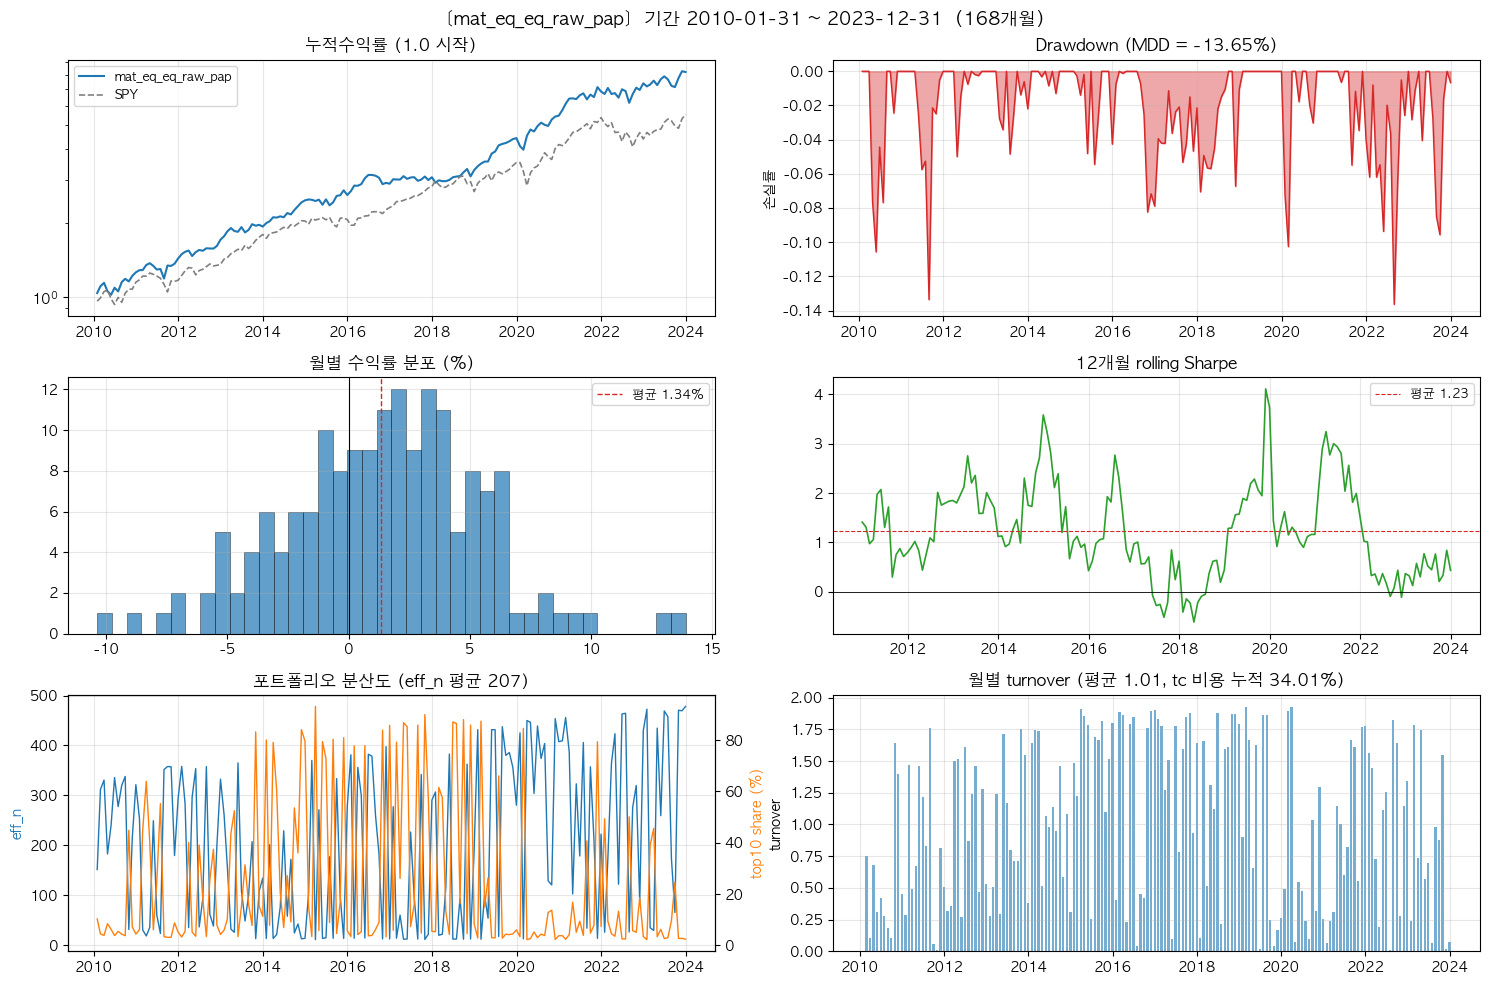


[Config]
  p_mode          = lstm_predicted
  p_weight        = eq
  q_mode          = raw_lam
  q_value         = 0.003
  omega_mode      = ff3_paper
  prior           = capm_eq
  tc              = 0.002
  max_weight      = 0.1
  lam_mean        = 2.5

[Metrics]
  Sharpe   = 1.096
  Sortino  = 1.826
  CAGR     = 16.25%
  Vol      = 13.85%
  MDD      = -13.65%
  Calmar   = 1.191
  Beta     = -0.181
  Alpha    = 17.45%
  WinRate  = 64.3%


In [7]:
# ────────────────────────────────────────────────────────────────────
# 예시 1 — 단일 실험 종합 분석
# ────────────────────────────────────────────────────────────────────
name   = 'mat_eq_eq_raw_pap'        # ← 다른 실험 보려면 이 줄만 변경
period = ('2010-01', '2023-12')           # ← 기간 변경 가능 (예: ('2013-01', '2024-12'))

plot_single(name, period=period)

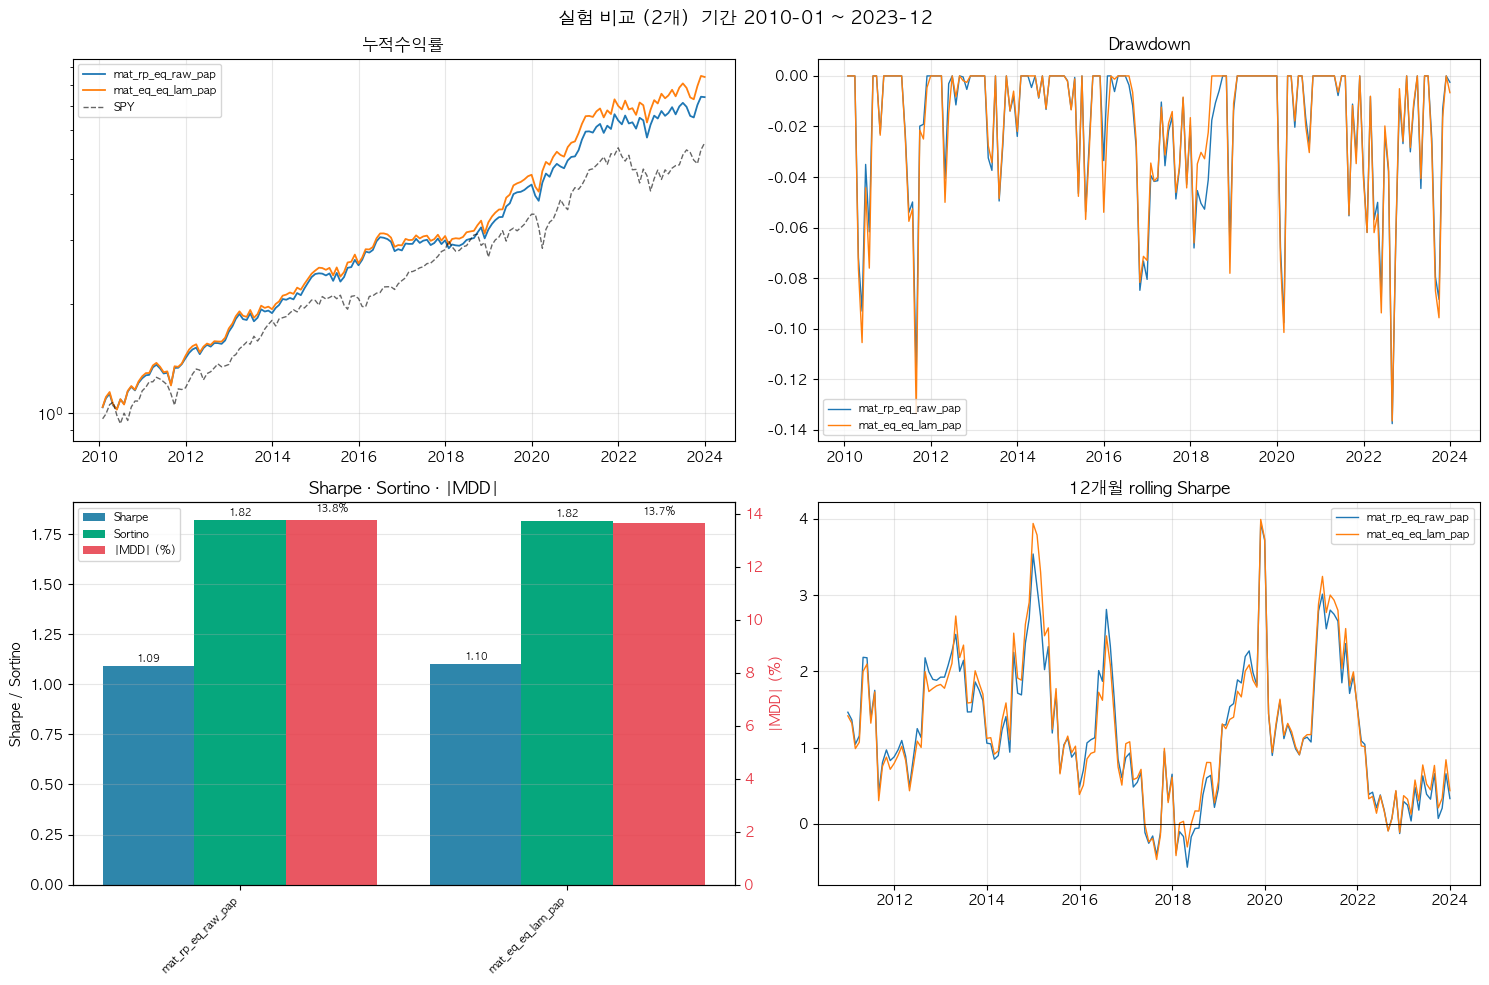


[Metrics 표]
             name  n_month  Sharpe  Sortino   CAGR    Vol     MDD  Calmar   Beta  Alpha WinRate
mat_rp_eq_raw_pap      168   1.093    1.819 15.38% 13.09% -13.75%   1.118 -0.166 16.40%  64.90%
mat_eq_eq_lam_pap      168   1.102    1.816 16.44% 13.94% -13.65%   1.205 -0.190 17.74%  66.10%


In [8]:
# ────────────────────────────────────────────────────────────────────
# 예시 2 — 여러 실험 비교 (Q 모드 차이 — raw vs lam)
# ────────────────────────────────────────────────────────────────────
names = [
    'mat_rp_eq_raw_pap',
    'mat_eq_eq_lam_pap'
]

plot_compare(names, period=('2010-01', '2023-12'))

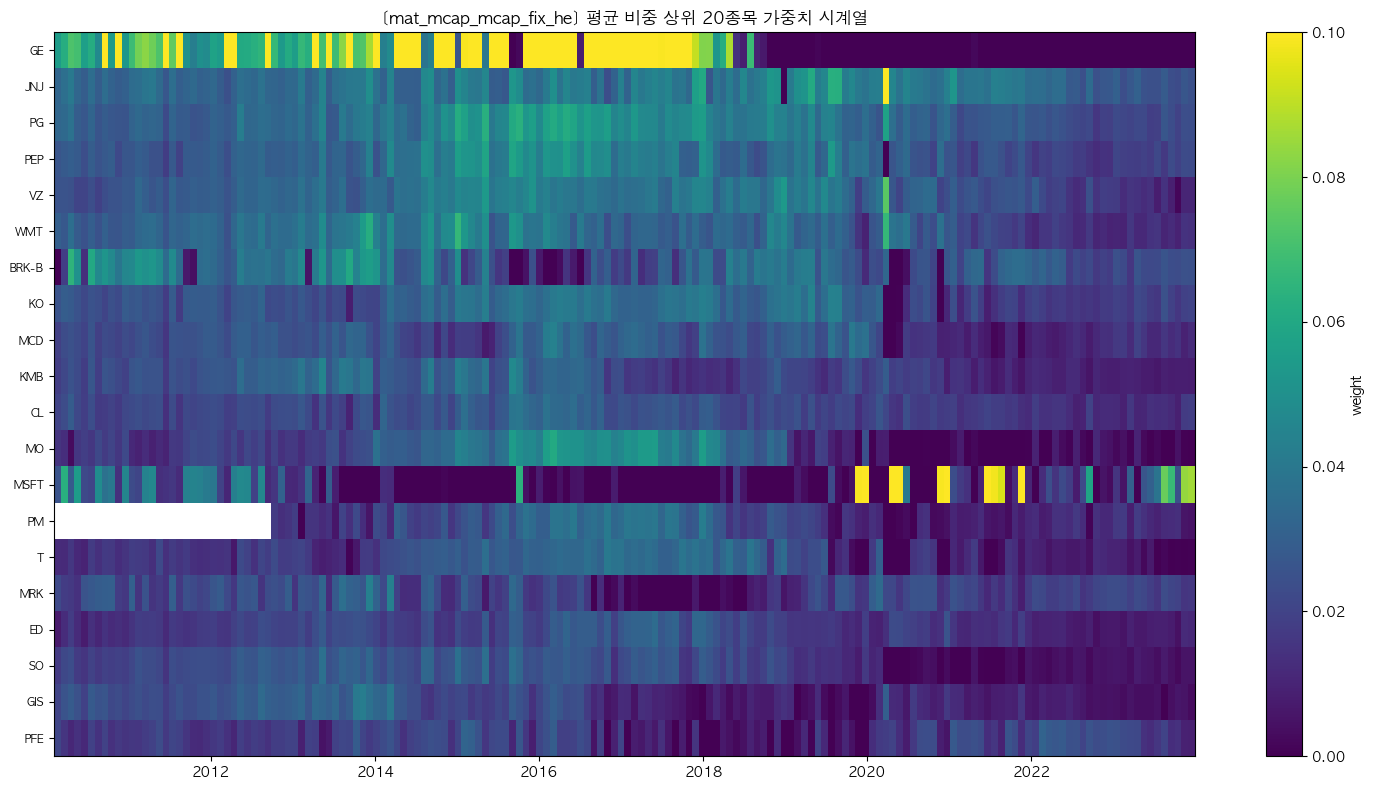

In [9]:
# ────────────────────────────────────────────────────────────────────
# 예시 4 — 가중치 heatmap
# ────────────────────────────────────────────────────────────────────
name = 'mat_mcap_mcap_fix_he'

plot_weights(name, n_top=20)

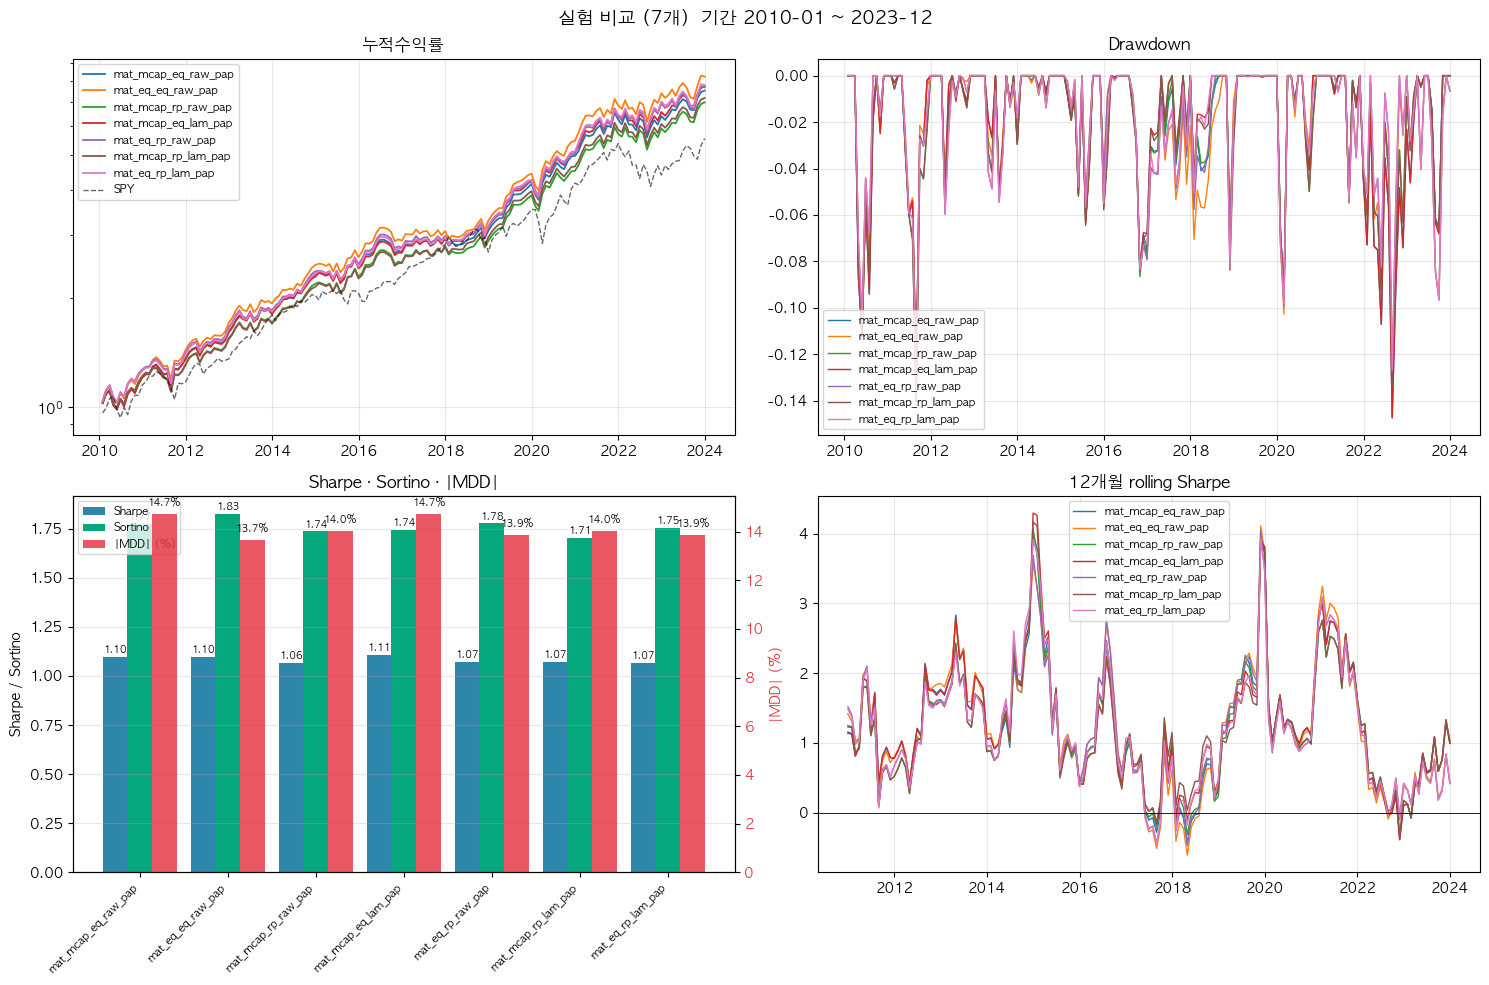


[Metrics 표]
               name  n_month  Sharpe  Sortino   CAGR    Vol     MDD  Calmar   Beta  Alpha WinRate
mat_mcap_eq_raw_pap      168   1.099    1.775 15.52% 13.15% -14.73%   1.054 -0.156 16.41%  64.30%
  mat_eq_eq_raw_pap      168   1.096    1.826 16.25% 13.85% -13.65%   1.191 -0.181 17.45%  64.30%
mat_mcap_rp_raw_pap      168   1.064    1.736 14.90% 13.07% -14.03%   1.062 -0.150 15.77%  64.30%
mat_mcap_eq_lam_pap      168   1.106    1.742 15.73% 13.25% -14.73%   1.068 -0.164 16.71%  64.30%
  mat_eq_rp_raw_pap      168   1.069    1.777 15.69% 13.73% -13.87%   1.132 -0.171 16.81%  63.70%
mat_mcap_rp_lam_pap      168   1.070    1.705 15.13% 13.19% -14.03%   1.078 -0.158 16.09%  64.30%
  mat_eq_rp_lam_pap      168   1.067    1.753 15.80% 13.86% -13.87%   1.140 -0.181 17.06%  65.50%


In [10]:
# ────────────────────────────────────────────────────────────────────
# 예시 5 — sortino_ir Top 후보 7 개 종합 비교 (prior/pw/q 다양한 조합)
# ────────────────────────────────────────────────────────────────────
names = [
    'mat_mcap_eq_raw_pap',
    'mat_eq_eq_raw_pap',
    'mat_mcap_rp_raw_pap',
    'mat_mcap_eq_lam_pap',
    'mat_eq_rp_raw_pap',
    'mat_mcap_rp_lam_pap',
    'mat_eq_rp_lam_pap'
]

plot_compare(names, period=('2010-01', '2023-12'))

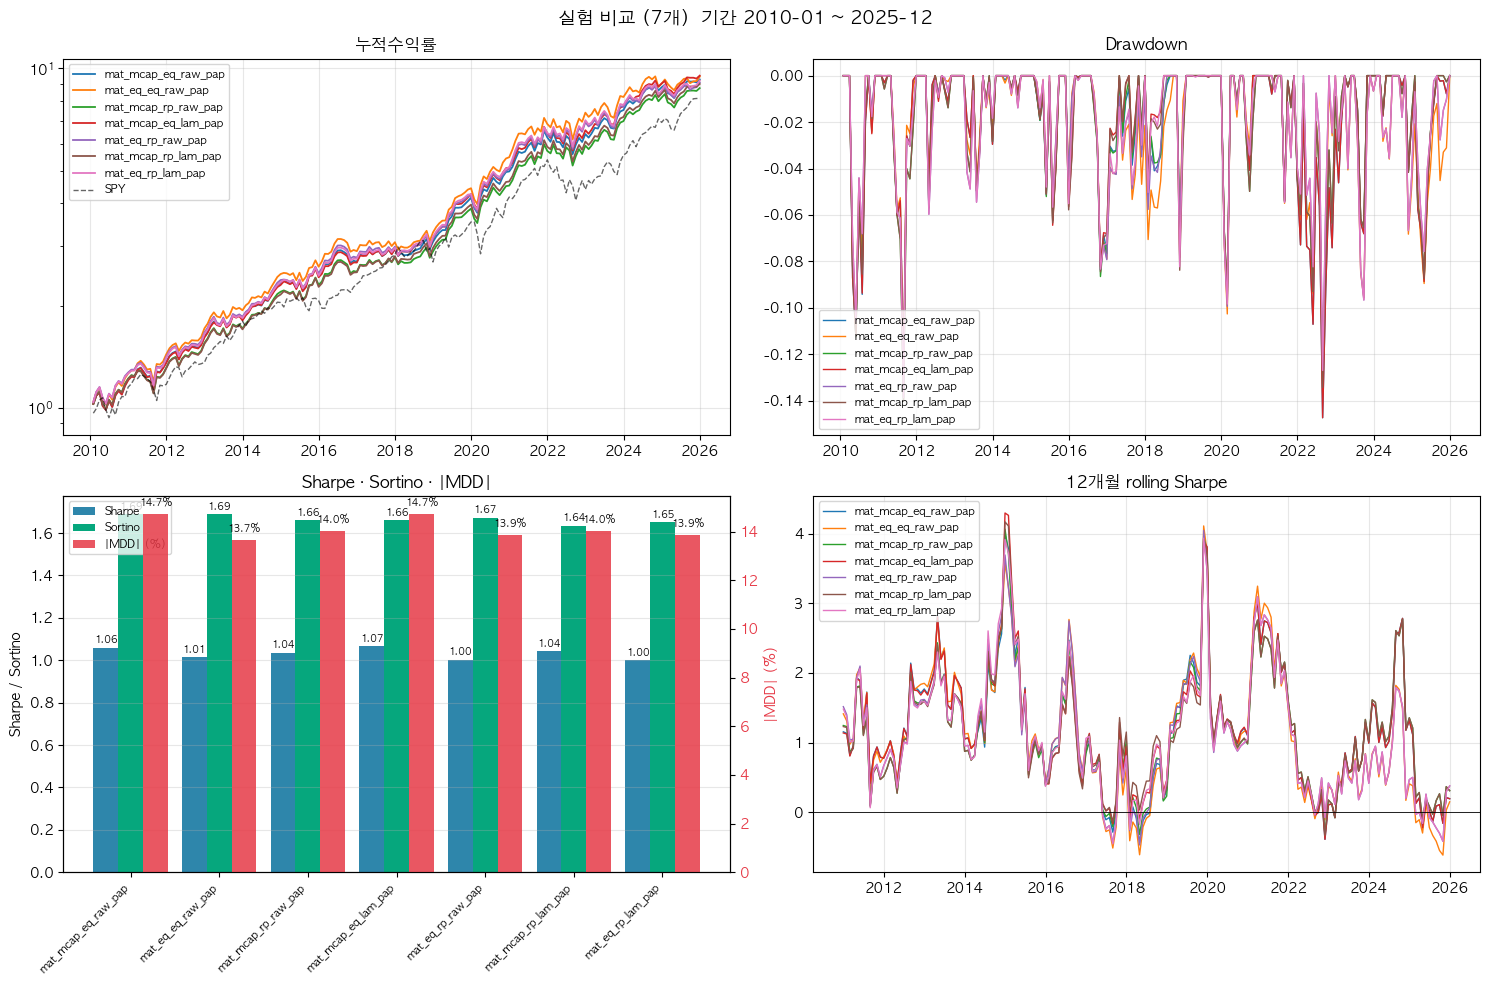


[Metrics 표]
               name  n_month  Sharpe  Sortino   CAGR    Vol     MDD  Calmar   Beta  Alpha WinRate
mat_mcap_eq_raw_pap      192   1.060    1.691 14.93% 12.67% -14.73%   1.014 -0.139 15.24%  64.60%
  mat_eq_eq_raw_pap      192   1.014    1.691 15.08% 13.46% -13.65%   1.105 -0.167 15.83%  64.60%
mat_mcap_rp_raw_pap      192   1.036    1.662 14.51% 12.61% -14.03%   1.035 -0.132 14.78%  65.10%
mat_mcap_eq_lam_pap      192   1.066    1.662 15.12% 12.76% -14.73%   1.027 -0.147 15.52%  64.60%
  mat_eq_rp_raw_pap      192   1.003    1.673 14.79% 13.33% -13.87%   1.066 -0.157 15.42%  64.10%
mat_mcap_rp_lam_pap      192   1.042    1.635 14.71% 12.72% -14.03%   1.049 -0.140 15.07%  65.10%
  mat_eq_rp_lam_pap      192   1.002    1.653 14.88% 13.45% -13.87%   1.073 -0.166 15.64%  65.60%


In [11]:
# ────────────────────────────────────────────────────────────────────
# 예시 6 — hold-out 24m 포함 비교 (FULL 192m)
# ────────────────────────────────────────────────────────────────────
names = [
    'mat_mcap_eq_raw_pap',
    'mat_eq_eq_raw_pap',
    'mat_mcap_rp_raw_pap',
    'mat_mcap_eq_lam_pap',
    'mat_eq_rp_raw_pap',
    'mat_mcap_rp_lam_pap',
    'mat_eq_rp_lam_pap'
]

# K_CUT 후 R4 hold-out 까지 포함 (winner R4 underperform 확인용)
plot_compare(names, period=('2010-01', '2025-12'))

In [12]:
# ────────────────────────────────────────────────────────────────────
# 예시 7 — 전체 metrics 표 (Sharpe 순)
# ────────────────────────────────────────────────────────────────────
all_names = list_results()
df = metrics_summary(all_names, period=('2010-01', '2023-12'))
df_sorted = df.sort_values('Sharpe', ascending=False)

# 표시 포맷
fmt = df_sorted.copy()
for col in ['CAGR', 'Vol', 'MDD', 'Alpha', 'WinRate']:
    fmt[col] = fmt[col].apply(
        lambda x: f'{x*100:.2f}%' if isinstance(x, (int, float)) and not pd.isna(x) else 'N/A')
for col in ['Sharpe', 'Sortino', 'Calmar', 'Beta']:
    fmt[col] = fmt[col].apply(
        lambda x: f'{x:.3f}' if isinstance(x, (int, float)) and not pd.isna(x) else 'N/A')

print(fmt.to_string(index=False))

                 name  n_month Sharpe Sortino   CAGR    Vol     MDD Calmar   Beta  Alpha WinRate
  mat_mcap_eq_lam_pap      168  1.106   1.742 15.73% 13.25% -14.73%  1.068 -0.164 16.71%  64.30%
    mat_eq_eq_lam_pap      168  1.102   1.816 16.44% 13.94% -13.65%  1.205 -0.190 17.74%  66.10%
  mat_mcap_eq_raw_pap      168  1.099   1.775 15.52% 13.15% -14.73%  1.054 -0.156 16.41%  64.30%
    mat_rp_eq_lam_pap      168  1.099   1.808 15.55% 13.16% -13.75%  1.131 -0.174 16.67%  66.10%
    mat_eq_eq_raw_pap      168  1.096   1.826 16.25% 13.85% -13.65%  1.191 -0.181 17.45%  64.30%
    mat_rp_eq_fix_pap      168  1.096   1.711 15.53% 13.18% -12.42%  1.250 -0.178 16.70%  64.30%
    mat_rp_eq_raw_pap      168  1.093   1.819 15.38% 13.09% -13.75%  1.118 -0.166 16.40%  64.90%
    mat_eq_eq_fix_pap      168  1.091   1.709 16.33% 13.99% -13.14%  1.243 -0.193 17.69%  65.50%
    mat_rp_rp_lam_pap      168  1.079   1.790 15.17% 13.09% -12.84%  1.182 -0.168 16.24%  66.70%
    mat_rp_rp_raw_pap      168

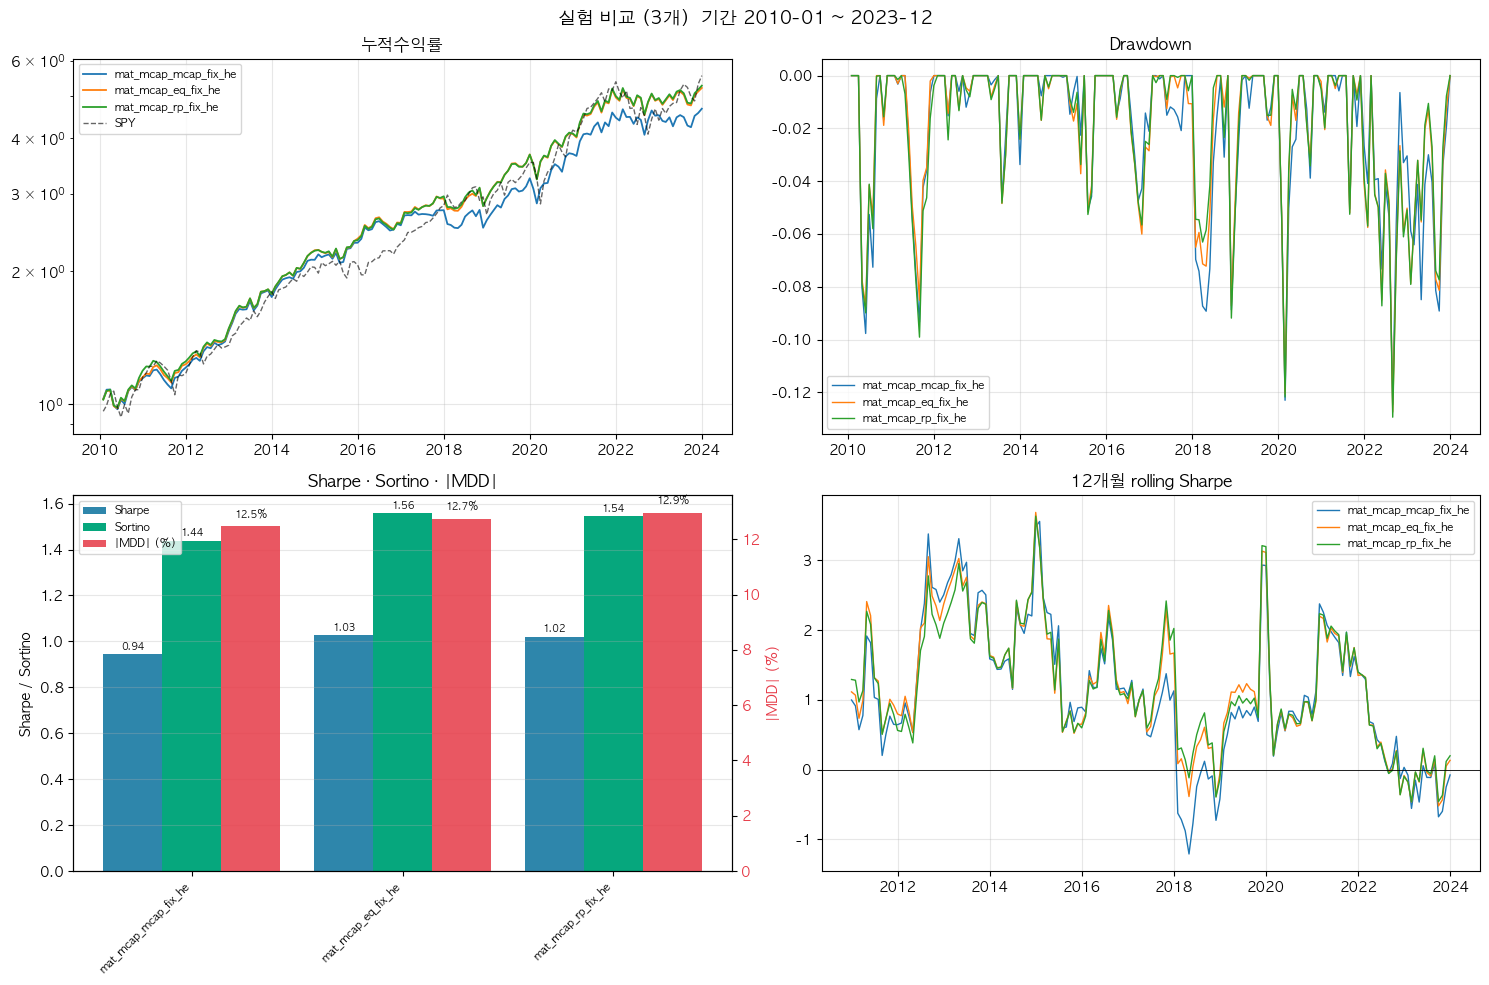


[Metrics 표]
                name  n_month  Sharpe  Sortino   CAGR    Vol     MDD  Calmar   Beta  Alpha WinRate
mat_mcap_mcap_fix_he      168   0.943    1.439 11.63% 11.40% -12.46%   0.934 -0.118 12.26%  64.30%
  mat_mcap_eq_fix_he      168   1.026    1.558 12.50% 11.21% -12.74%   0.981 -0.118 13.03%  61.90%
  mat_mcap_rp_fix_he      168   1.021    1.545 12.60% 11.38% -12.94%   0.973 -0.115 13.09%  62.50%


In [13]:
# ────────────────────────────────────────────────────────────────────
# 예시 8 — 자유 탐색 (목적별 그룹 비교)
# ────────────────────────────────────────────────────────────────────
# (a) p_weight 효과만 비교 (prior=mcap, q=fixed, omega=he 고정)
names_a = ['mat_mcap_mcap_fix_he', 'mat_mcap_eq_fix_he', 'mat_mcap_rp_fix_he']
plot_compare(names_a, period=('2010-01', '2023-12'))

# (b) prior 효과만 비교 (p_weight=mcap 고정)
# names_b = ['mat_mcap_mcap_fix_he', 'mat_eq_mcap_fix_he', 'mat_rp_mcap_fix_he']
# plot_compare(names_b)